# ReGRID model analysis

### Energy system configurations

Last update: 4 March, 2026

Dependency: model.py

In [23]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import math

In [24]:
# Chart paramter
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.major.width'] = 0.3
plt.rcParams['ytick.major.width'] = 0.3
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['font.size'] = 5
plt.rcParams['xtick.labelsize'] = 5
plt.rcParams['ytick.labelsize'] = 5
plt.rcParams['axes.linewidth'] = 0.3

MAX_WIDTH = 180 / 25.4 # inch in 180mm

In [25]:
TECH_SCENARIO = 'TechBase'

In [26]:
CASE = ['base','low','mid','high']
VRE = ['solar','onwin','of-fx','of-fl']

P = pd.read_csv(f'input/technology/technology_C1.csv', index_col=0)
P = P[(P['year'] == 2050) & (P['scenario'] == 'moderate')]
SPACE = dict([(res, P['land'][res]) for res in VRE])
COLOR = dict([(res, P['color'][res]) for res in VRE])

potential = pd.read_csv('output/analysis/potential_summary.csv', index_col=['code','tech'])
capacity = pd.read_csv(f'output/analysis/capacity_summary_2050_{TECH_SCENARIO}.csv', index_col=['code','tech'])
area_total = pd.DataFrame(index=CASE, columns=VRE)

for res in VRE:
    for case in CASE:
        area_total[res][case] = capacity.xs(res, level="tech")[case].sum() * SPACE[res]

area_total

,solar,onwin,of-fx,of-fl
base,4505.159843,720.626347,16053.250033,3502.545669
low,4757.886107,745.314467,8157.078336,9551.089537
mid,5325.626539,522.682824,4621.025925,11475.828037
high,4397.350341,66.95,2444.684596,16556.841602


In [27]:
# Overlaping area

capacity_risk = {}
area_risk = {}

for case in CASE:
    area_risk[case] = pd.DataFrame(index=CASE, columns=VRE)
    capacity_risk[case] = pd.DataFrame(columns=CASE)
    
    for potential_case in CASE:
        capacity_risk[case][potential_case] = (capacity[case] - potential[potential_case]).where(capacity[case] > potential[potential_case], 0)
        
    for res in VRE:
        area_risk[case][res] = capacity_risk[case].xs(res, level="tech").sum() * SPACE[res]

area_risk['base']

,solar,onwin,of-fx,of-fl
base,0.000000,0.000000,0.000000,0.000000
low,540.642249,331.823695,9633.956068,35.700000
mid,677.935489,574.856199,13003.125728,2185.873183
high,2656.136235,712.476347,14549.852314,2477.703364


In [ ]:
# Overlap ratio (Renewables deployment area in 1.5C-HPA overlap with PCAs in FullProtect)

overlap_ratio = area_risk['base'].T['high'] / area_total.T['base']
overlap_ratio

solar    0.589576
onwin     0.98869
of-fx    0.906349
of-fl    0.707401
dtype: object

In [29]:

def color_layer(base_color, layer_color, a, n):
    if not (0 <= a <= 1):
        raise ValueError("a must be in [0, 1]")
    if n < 0:
        raise ValueError("n must be >= 0")

    rb, gb, bb = mcolors.to_rgb(base_color)
    rs, gs, bs = mcolors.to_rgb(layer_color)

    alpha_eff = 1 - (a ** n)   # Opacity

    r = rs * alpha_eff + rb * (1 - alpha_eff)
    g = gs * alpha_eff + gb * (1 - alpha_eff)
    b = bs * alpha_eff + bb * (1 - alpha_eff)

    return mcolors.to_hex((r, g, b))

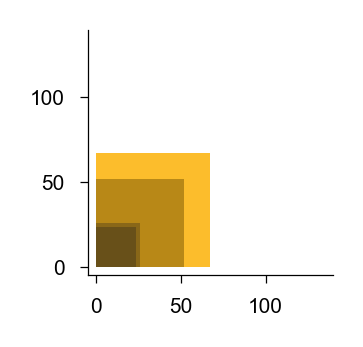

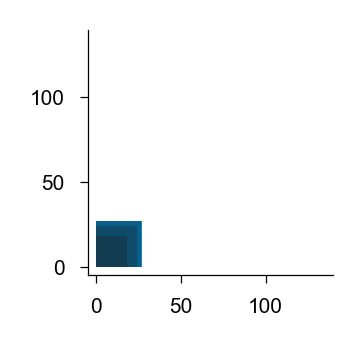

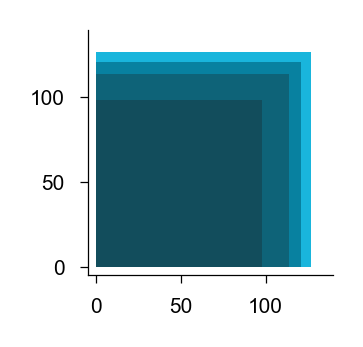

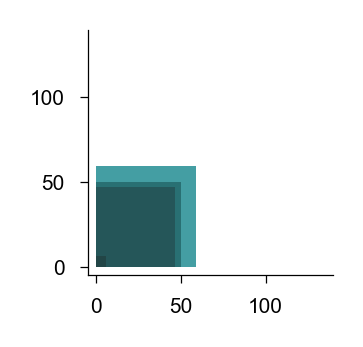

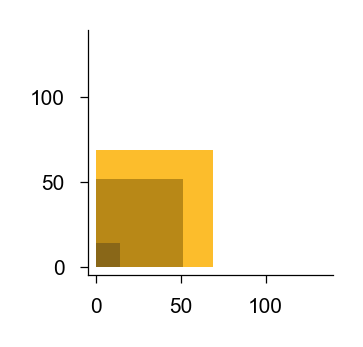

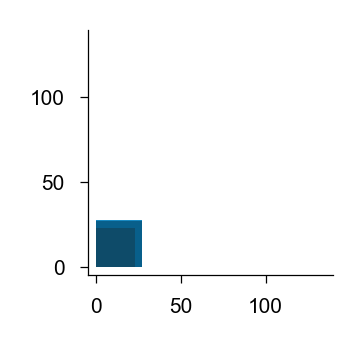

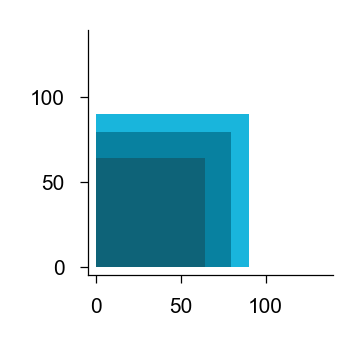

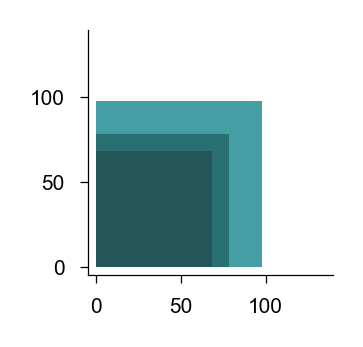

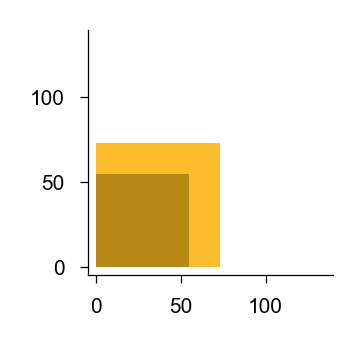

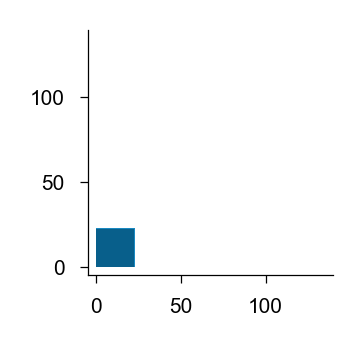

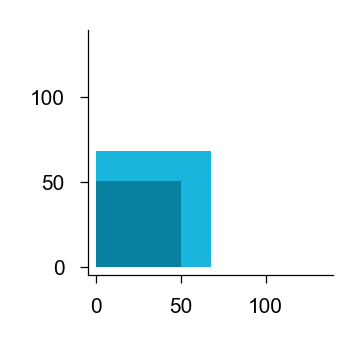

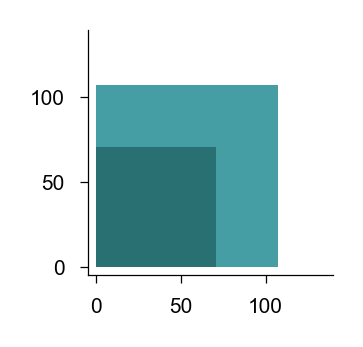

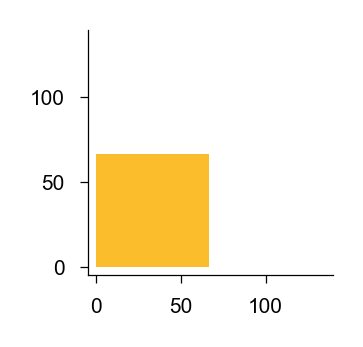

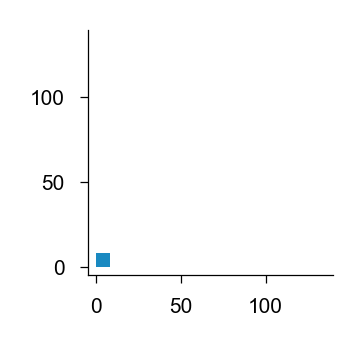

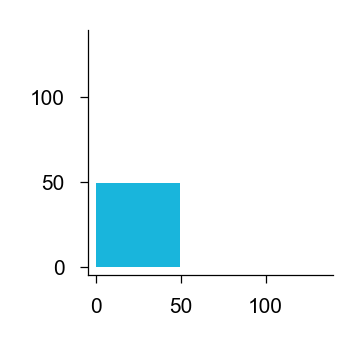

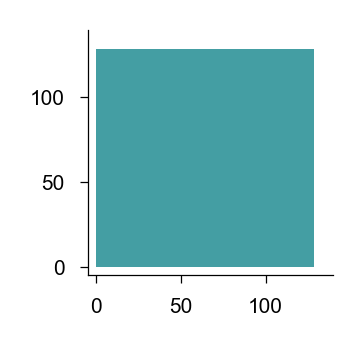

In [30]:
# Generate renewables area charts

for m, base_case in enumerate(CASE):
    for res in VRE:
        fig, ax = plt.subplots(figsize=[MAX_WIDTH*0.15,MAX_WIDTH*0.15], dpi=300)
        area = area_total[res][base_case]
        ax.add_patch(Rectangle((0, 0), math.sqrt(area), math.sqrt(area), facecolor=COLOR[res], alpha=0.9, linewidth=0))

        for n, case in enumerate(CASE[::-1]):
            area = area_risk[base_case][res][case]
            ax.add_patch(Rectangle((0, 0), math.sqrt(area), math.sqrt(area), facecolor=color_layer(COLOR[res], "#1B1B1B", 0.7, n+1), alpha=1, linewidth=0))

        ax.set_xlim(-5, 140)
        ax.set_ylim(-5, 140)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_aspect("equal", adjustable="box")

        plt.savefig(f'output/analysis/renewables_area/square_{TECH_SCENARIO}_{res}_{base_case}.png', bbox_inches='tight', pad_inches=0, dpi=300)
        plt.savefig(f'output/analysis/renewables_area/square_{TECH_SCENARIO}_{res}_{base_case}.pdf', bbox_inches='tight', pad_inches=0)
        plt.show()

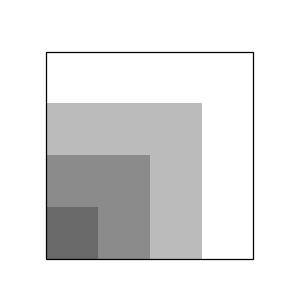

In [ ]:
fig, ax = plt.subplots(figsize=[MAX_WIDTH*0.15,MAX_WIDTH*0.15], dpi=300)

legend_size = math.sqrt(4000)

ax.add_patch(Rectangle((0, 0), legend_size*3/4, legend_size*3/4, facecolor=color_layer("#ffffff", "#1B1B1B", 0.7, 1), alpha=1, linewidth=0))
ax.add_patch(Rectangle((0, 0), legend_size*2/4, legend_size*2/4, facecolor=color_layer("#ffffff", "#1B1B1B", 0.7, 2), alpha=1, linewidth=0))
ax.add_patch(Rectangle((0, 0), legend_size*1/4, legend_size*1/4, facecolor=color_layer("#ffffff", "#1B1B1B", 0.7, 3), alpha=1, linewidth=0))
ax.add_patch(Rectangle((0, 0), legend_size, legend_size, fill=False, edgecolor="#000000", linewidth=0.3))
ax.set_xlim(-5, 70)
ax.set_ylim(-5, 70)

ax.set_aspect("equal", adjustable="box")
ax.set_axis_off()

plt.savefig(f'output/square_legend.png', bbox_inches='tight', dpi=300)
plt.savefig(f'output/square_legend.pdf', bbox_inches='tight')
plt.show()